# ⚗️ Advanced Simulator: Emulsion Engineering & Thermodynamics

### Welcome, Chemical Engineers!
Manufacturing photographic film is all about controlling the size and distribution of Silver Halide ($AgBr$) crystals. 
* **Big crystals** catch more light (High ISO) but look grainy.
* **Small crystals** catch less light (Low ISO) but look incredibly sharp.

If all the crystals are the *exact same size*, they all turn black at the exact same time, creating a very **High Contrast** image. If there is a wide mix of big and small crystals, they turn black at different rates, creating a smooth, **Low Contrast** image with lots of gray tones.

**Professor Instructions:** Run the cells below to simulate how precipitation rates and Ostwald Ripening dictate the physical properties of your film.

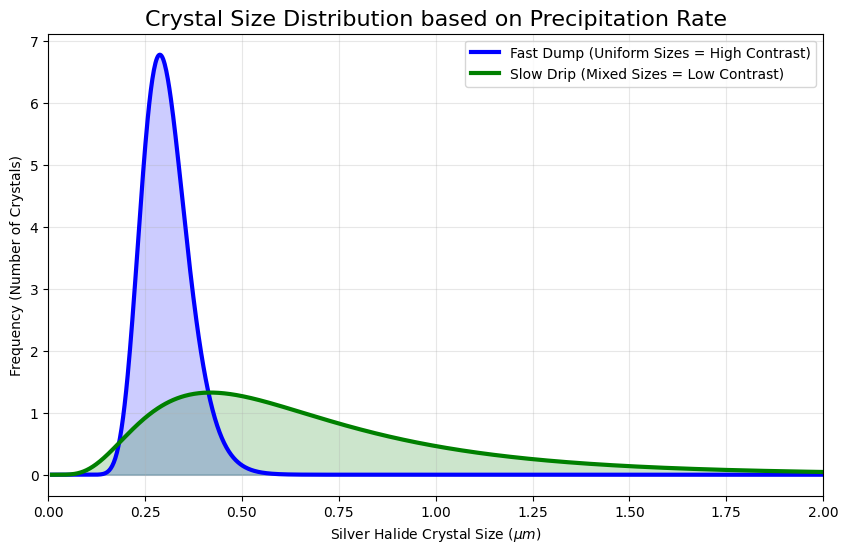

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

def simulate_precipitation_rate():
    """
    Simulates how the speed of mixing Silver Nitrate and Potassium Bromide 
    affects the variance of crystal sizes, which directly determines film contrast.
    """
    # X-axis: Crystal Size in micrometers (um)
    sizes = np.linspace(0.01, 2.0, 1000)
    
    # Scenario A: The "Fast Dump" (High Contrast Film)
    # All silver is added at once. Crystals form rapidly and are uniformly small.
    # We model this with a narrow log-normal distribution.
    fast_dump = lognorm.pdf(sizes, s=0.2, scale=0.3)
    
    # Scenario B: The "Slow Drip" (Low Contrast / Wide Dynamic Range Film)
    # Silver is added slowly over 30 minutes. Early crystals grow large, 
    # while late crystals stay small. This creates a wide variance in sizes.
    slow_drip = lognorm.pdf(sizes, s=0.6, scale=0.6)
    
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, fast_dump, 'b-', linewidth=3, label="Fast Dump (Uniform Sizes = High Contrast)")
    plt.plot(sizes, slow_drip, 'g-', linewidth=3, label="Slow Drip (Mixed Sizes = Low Contrast)")
    
    # Fill under the curves for visualization
    plt.fill_between(sizes, fast_dump, alpha=0.2, color='blue')
    plt.fill_between(sizes, slow_drip, alpha=0.2, color='green')
    
    plt.title("Crystal Size Distribution based on Precipitation Rate", fontsize=16)
    plt.xlabel("Silver Halide Crystal Size ($\mu m$)")
    plt.ylabel("Frequency (Number of Crystals)")
    plt.xlim(0, 2.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Run the Precipitation Simulator!
simulate_precipitation_rate()

### 📊 Analysis of Precipitation
Look at the graph above. 
If you want to manufacture a high-contrast documentary film like Kodak Tri-X, you engineer your machinery to execute a rapid precipitation (the blue curve). If you are manufacturing a portrait film that needs smooth, gentle skin tones (like Kodak Portra), you engineer a slow, staggered precipitation (the green curve).

---

### 🔥 Thermodynamics: Ostwald Ripening
After precipitation, the crystals are still too small and insensitive. We must "cook" the emulsion at $55^\circ C$. 

According to the **Lifshitz-Slyozov-Wagner (LSW) Theory**, smaller crystals have higher surface energy and are more soluble. Over time, the smallest crystals will literally dissolve back into the liquid gelatin and redeposit onto the larger crystals. 

The equation for this growth over time ($t$) is:
$$r^3 - r_0^3 = K \cdot t$$
Where $r$ is the average crystal radius, $r_0$ is the initial radius, and $K$ is a constant dependent on temperature and solubility. Let's graph this!

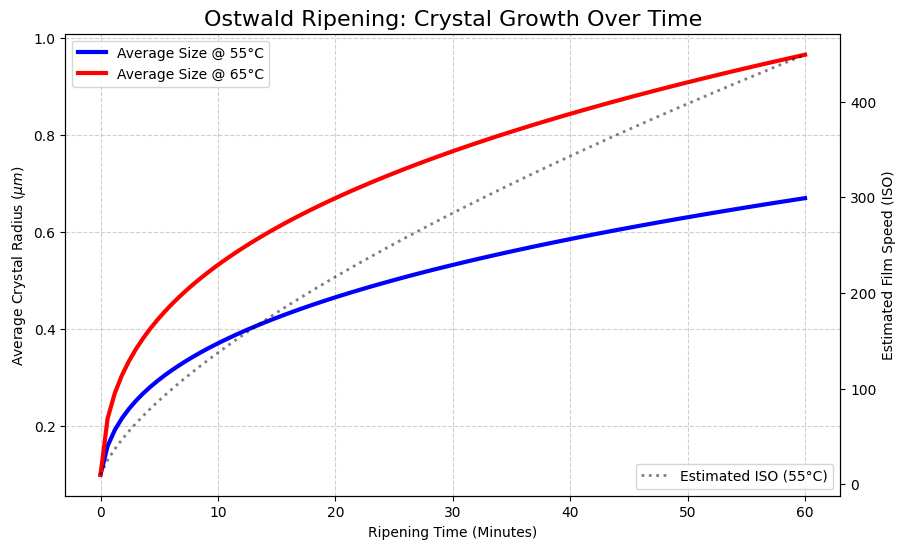

In [2]:
def simulate_ostwald_ripening():
    """
    Simulates the growth of average crystal size over time using a simplified LSW model.
    """
    time_minutes = np.linspace(0, 60, 100)
    
    # Initial radius (r_0) in micrometers
    r_0 = 0.1 
    
    # Rate constant (K) - increases with higher temperatures
    K_55C = 0.005  # Ripening at 55 Celsius
    K_65C = 0.015  # Ripening at 65 Celsius
    
    # LSW Equation: r = cbrt(r_0^3 + K*t)
    radius_55C = np.cbrt((r_0**3) + (K_55C * time_minutes))
    radius_65C = np.cbrt((r_0**3) + (K_65C * time_minutes))
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    ax1.plot(time_minutes, radius_55C, 'b-', linewidth=3, label="Average Size @ 55°C")
    ax1.plot(time_minutes, radius_65C, 'r-', linewidth=3, label="Average Size @ 65°C")
    
    ax1.set_title("Ostwald Ripening: Crystal Growth Over Time", fontsize=16)
    ax1.set_xlabel("Ripening Time (Minutes)")
    ax1.set_ylabel("Average Crystal Radius ($\mu m$)")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc="upper left")
    
    # Add a secondary Y-axis to show the estimated ISO speed gain
    ax2 = ax1.twinx()
    # Simplified assumption: ISO is proportional to the cross-sectional area (r^2)
    iso_estimate = (radius_55C / r_0)**2 * 10 
    ax2.plot(time_minutes, iso_estimate, 'k:', linewidth=2, alpha=0.5, label="Estimated ISO (55°C)")
    ax2.set_ylabel("Estimated Film Speed (ISO)")
    ax2.legend(loc="lower right")
    
    plt.show()

# Run the Thermodynamics Simulator!
simulate_ostwald_ripening()

### 🔬 The Engineering Trade-off
Look at the red line vs the blue line. 
By increasing the temperature of the water bath by just $10^\circ C$, the crystals grow exponentially faster. This pushes the ISO (film speed) up dramatically. 

However, in thermodynamics, there is no free lunch. If you let the Ostwald Ripening go on for too long, the crystals get so large that the final photograph will look incredibly grainy, and the unexposed silver might begin to spontaneously develop (creating base fog). 

As an emulsion engineer, your job is to perfectly balance the Time, Temperature, and Precipitation Rate to create a stable, beautiful film!